# Operaciones morfológicas

In [1]:
import imageio.v3 as iio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
!rm -fr sample_data
!git clone https://github.com/jmbajo/diplodatos-demo-imgs.git
!mv diplodatos-demo-imgs/* .
!rm -rf diplodatos-demo-imgs

Cloning into 'diplodatos-demo-imgs'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 19 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 6.27 MiB | 10.37 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [3]:
MAT_RGB2YIQ = np.array([[0.299, 0.587, 0.114],
                        [0.596,-0.275,-0.321],
                        [0.211,-0.523, 0.311]])

def apply_matrix(img, M):
    return np.matmul( img.reshape((-1,3)), M.T ).reshape(img.shape)

Imageio: 'astronaut.png' was not found on your computer; downloading it now.
Try 1. Download from https://github.com/imageio/imageio-binaries/raw/master/images/astronaut.png (773 kB)
Downloading: 8192/791555 bytes (1.0%)791555/791555 bytes (100.0%)
  Done
File saved as /root/.imageio/images/astronaut.png.


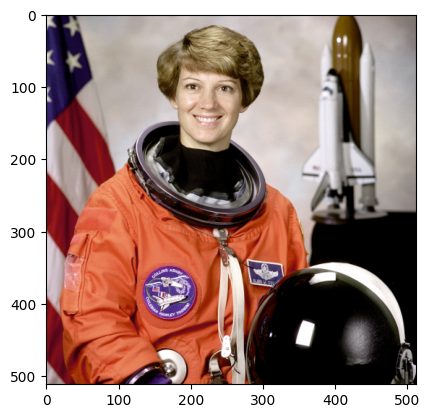

In [4]:
img_rgb = iio.imread('imageio:astronaut.png')
plt.imshow(img_rgb)

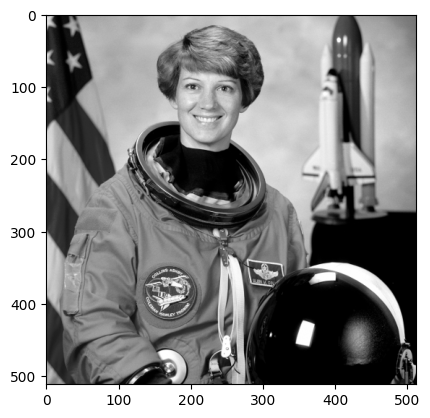

In [5]:
img_rgb = iio.imread('imageio:astronaut.png') / 255
plt.imshow(img_rgb)

img_YIQ = apply_matrix(img_rgb, MAT_RGB2YIQ)
canal_Y = img_YIQ[:,:,0]

plt.imshow(canal_Y, 'gray')



<font color='#ff4d00'>Ejercicio: Implementar las operaciones de erosión y dilatación para una imagen en escala de grises, Verificar su funcionamiento en una imagen binaria.</font>

In [6]:
def erosion(imagen):
    # Resolver
    pass


def dilatacion(imagen):
    filas = imagen.shape[0]
    columnas = imagen.shape[1]

    output = np.zeros((filas, columnas), dtype='float64')

    for i in range(1, filas-1):
        for j in range(1, columnas-1):
            ventana = imagen[i-1:i+2, j-1:j+2]
            maximo = ventana.flatten().max()
            output[i, j] = maximo

    output = output[1:filas-1, 1:columnas-1]
    return output

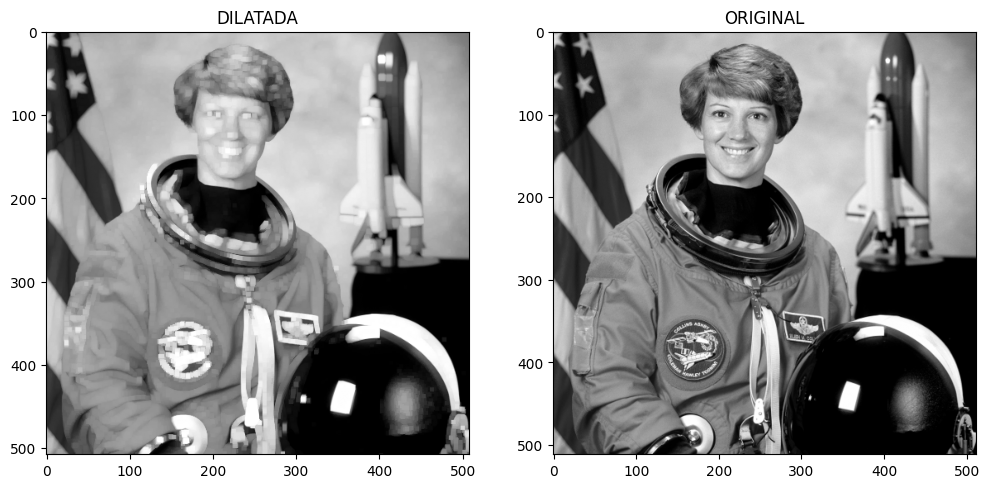

In [10]:
img_dilatada = dilatacion(dilatacion(canal_Y))


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('DILATADA')
plt.imshow(img_dilatada,"gray")

plt.subplot(1, 2, 2)
plt.title('ORIGINAL')
plt.imshow(canal_Y, cmap="gray")


plt.show()

# foto=canal_Y
# for i in range(5):
#     foto=dilatacion(foto)

# plt.imshow(foto,"gray")


# foto=canal_Y
# for i in range(5):
    # foto=erosion(foto)

# Convolución

<font color='#ff4d00'>Ejercicio: Implementar una función que dada una imagen
aplique eun kernel de convolución.</font>

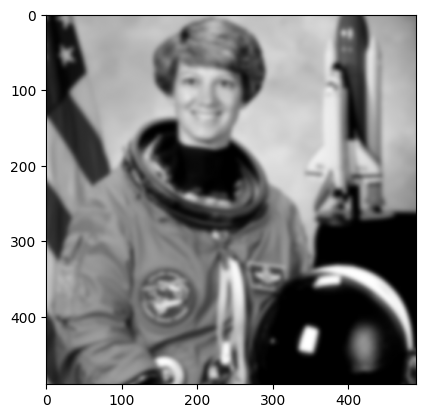

In [12]:
def convolucion(imagen, kernel):
    filas = imagen.shape[0]
    columnas = imagen.shape[1]

    output = np.zeros((filas, columnas), dtype='float64')

    for i in range(1, filas-1):
        for j in range(1, columnas-1):
            ventana = imagen[i-1:i+2, j-1:j+2]
            producto = ventana * kernel
            output[i, j] = producto.sum()

    output = output[1:filas-1, 1:columnas-1]
    return output


for _ in range(10):
    salida_conv = convolucion(salida_conv, np.ones((3,3)) / 9)

plt.imshow(salida_conv,"gray")

In [16]:
import plotly.express as px

In [18]:
kernel= np.zeros((3,3))
kernel[0,0]=-1
kernel[1,0]=-2
kernel[2,0]=-1

kernel[0,2]=1
kernel[1,2]=2
kernel[2,2]=1

print(kernel)

# foto=canal_Y
salida_conv_2=convolucion(canal_Y, kernel.T)
px.imshow(salida_conv_2, color_continuous_scale="gray")

Output hidden; open in https://colab.research.google.com to view.